# Анализ сходимости метода Якоби для $y''-y'+2y=-1$ на отрезке $[0,1]$


In [1]:
import numpy as np
from problems.lin_generator import Legandre
from problems.lin_generator import Chebyshev
from solver.Linear import Jacobi
from problems.lin_generator import ODE
import matplotlib.pyplot as plt
from tqdm import tqdm
from problems.lin_generator import BoundaryCondition

In [2]:
n_hist=[]
iter_hist=[]

In [3]:
n = 16 # колво итераций для первих двух
y0 = 0  # границы 
y1 = 0
tol = 1e-5 #- ошибка в посл графике
max23 = 10000000 #- колво итераций в последнем графике (итерации от n)
p = lambda x: 2 #- все три параметри уравнения
q = lambda x: -1
f = lambda x: -1

### Пишем генератор матриц СЛАУ для уравнения

(y_i+1 - 2*y_i + y_i-1) / h^2 + p*(y_i+1 - y_i-1) / 2h + k*y = 1

... * y_i-1 + ... * y_i + ... * y_i+1 = ...

n = 5

0 -> * --- * --- * --- * --- * <- 1

In [4]:
bc = BoundaryCondition(-1, -1, y0, y1)

x = ODE(p, q, f, bc)
A, b = x.generate_system(n)
print("ecgt[")

ecgt[


### Решаем матрицу итерационно (методом якоби)

In [5]:
solver = Jacobi()
solver.solve(A, b)

True

---

In [6]:
y_1 = solver.get_solution()
x_1 = x.x_grid
err=solver.get_history()
iter=solver.get_iter_count()

Ищем корни характеристического многочлена, получаем решение:$$y(x) = C_1 e^{(-1+\sqrt{2})x} + C_2 e^{(-1-\sqrt{2})x} + 1$$

In [7]:
k1 = -1 + np.sqrt(2)
k2 = -1 - np.sqrt(2)
l1 = np.array([[np.exp(k1 * 0),  np.exp(k2 * 0)], [np.exp(k1 * 1), np.exp(k2 * 1)]])
z1 = np.array([y0 - 1, y1 - 1])
C1,C2 = np.linalg.solve(l1, z1)


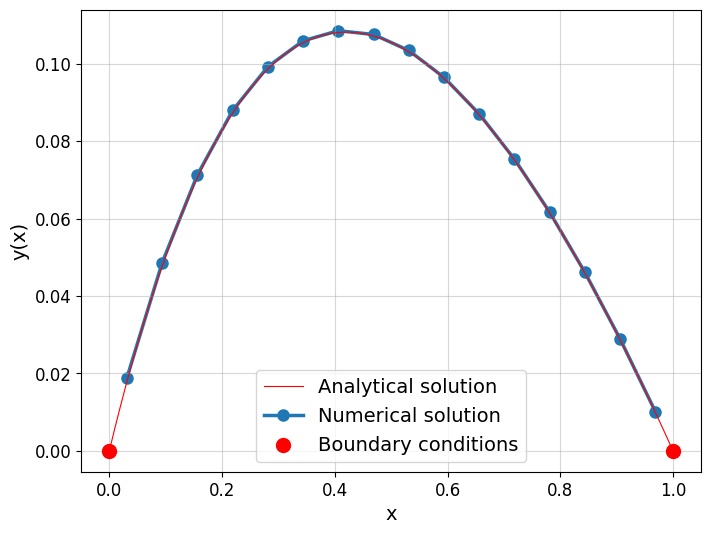

In [8]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
nd = np.linspace(0, 1, n, endpoint=True)
nd_fine = np.linspace(0, 1, 200, endpoint=True)
rel_sol = C1 * np.exp(k1 * nd_fine) + C2 * np.exp(k2 * nd_fine) + 1
plt.plot( nd_fine,rel_sol,color='red', lw=0.8, ms=0, label="Analytical solution", zorder=3)
plt.plot(x_1, y_1, '-o',lw=2.5, ms=8, label="Numerical solution", zorder=1)

plt.scatter((0,1), (y0, y1), color='red', s=100, label="Boundary conditions", zorder=2)

plt.xlabel('x', fontsize=14)
plt.ylabel('y(x)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=14)

plt.show()

-0.000230


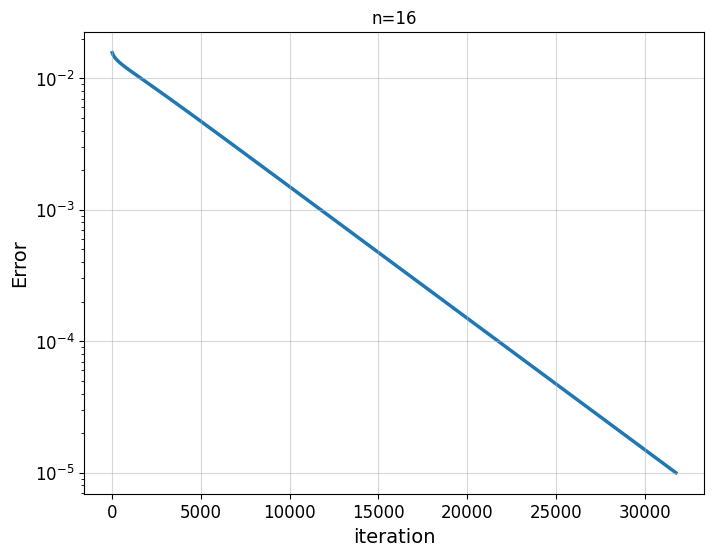

In [9]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
steps = np.arange(0, len(err), dtype=int)
half = len(err) // 2
x = steps[half:]
y=np.log(err[half:])
coeffs = np.polyfit(x, y, 1)
a, b = coeffs[0], coeffs[1]
err1 = np.exp(a*steps + b)
plt.plot(steps, err, lw=2.5, zorder=1)
plt.title(f"n={n}")
plt.xlabel('iteration', fontsize=14)
plt.ylabel('Error', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
print(f"{a:.6f}")
plt.show()

In [10]:
ns = [int(2**i) for i in range(1, 9)]
n_hist = []
iter_hist = []


for n in tqdm(ns):
    x = ODE(p, q, f, bc)
    A, b = x.generate_system(n)
    solver = Jacobi(1,tol,max23)
    solver.solve(A, b)
    iter_count = solver.get_iter_count()
    n_hist.append(n)
    iter_hist.append(iter_count)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [02:33<00:00, 19.16s/it]


-0.00023015133581434936


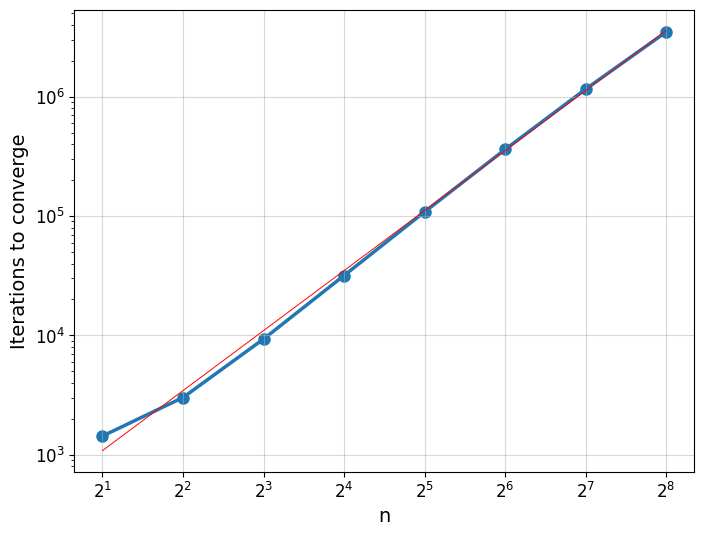

In [11]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
half = len(n_hist) // 2
x = np.log(n_hist[half:])
y=np.log(iter_hist[half:])
coeffs1 = np.polyfit(x, y, 1)
a1, b1 = coeffs1[0], coeffs1[1]
err1 = np.exp(b1) * (n_hist**a1)
plt.plot(n_hist, err1, lw=0.7, color='red', zorder=2)
plt.plot(n_hist, iter_hist, '-o', lw=2.5, ms=8, zorder=1)

# !!!
plt.xlabel('n', fontsize=14)
plt.ylabel('Iterations to converge', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xscale('log', base=2)
plt.yscale('log', base=10)
print(a)
plt.show()